# Unsupervised Learning

Unsupervised learning is a type of machine learning where the model is trained on unlabeled data. The goal is to find hidden patterns or intrinsic structures in the input data. Unlike supervised learning, there are no predefined labels or outcomes to guide the model.

## Methods
In general there are three types of unsupervised learning methods. 
- **Clustering**: Grouping data points based on their similarity using algorithms like K-means and DBSCAN.
- **Dimensionality Reduction**: Reducing the number of features while retaining important information using algorithms like PCA and t-SNE.
- **Association**: Discovering rules that describe large portions of the data using algorithms like Apriori and FP-Growth.

## Real-World Examples of Unsupervised Learning

Unsupervised learning is used in various real-world applications, including:

- **Customer Segmentation**: Grouping customers based on purchasing behavior for targeted marketing.
- **Anomaly Detection**: Identifying unusual patterns or outliers in data, useful in fraud detection.
- **Recommendation Systems**: Recommending products to users based on clustering similar user profiles.
- **Image Compression**: Reducing the size of image files by clustering similar pixels.


## K-means Clustering
K-means clustering is a popular unsupervised machine learning algorithm which partitions data into K clusters. Each cluster is defined by its centroid, which is the mean of the data points in the cluster.

Given a set of data points $ X = \{x_1, x_2, \ldots, x_n\} $, the K-means algorithm aims to partition the $ n $ data points into $ k $ clusters $ C = \{C_1, C_2, \ldots, C_k\} $ such that the within-cluster sum of squares (WCSS) is minimized. 

## Example: K-means Clustering on the Iris Dataset
Let's use the [Iris dataset](https://www.kaggle.com/datasets/uciml/iris) to demonstrate K-means clustering.

We start with importing necessary libraries and loading the Iris dataset. 

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

iris = load_iris()
data = iris.data
target = iris.target
target_names = iris.target_names

In this step, we are initializing a *StandardScaler* object and then using it to standardize our dataset. Standardization rescales the data to have a mean of 0 and a standard deviation of 1, which can improve the performance of many machine learning algorithms.

In [26]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

In this step, we are calculating the Within-Cluster Sum of Squares (WCSS) for different numbers of clusters, ranging from 1 to 10. This is done using the KMeans algorithm to help determine the optimal number of clusters by examining the WCSS values.

In [27]:
wcss = []  

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(data_scaled)
    wcss.append(kmeans.inertia_)

Here, we are plotting the within-Cluster Sum of Squares (WCSS) for different numbers of clusters to help identify the optimal number of clusters using the Elbow Method.

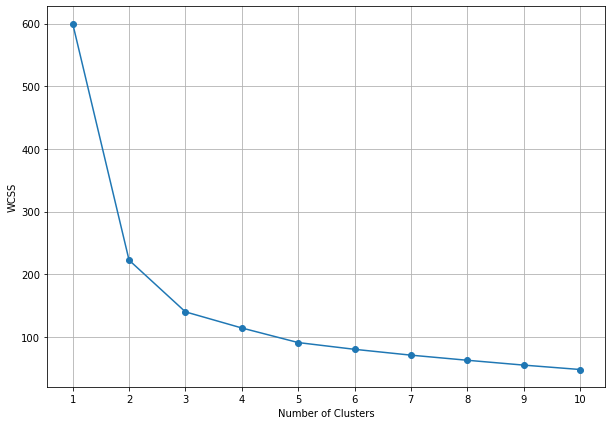

In [28]:
plt.figure(figsize=(10, 7))
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

Now, we select the optimal number of clusters based on the elbow plot and apply the K-Means clustering algorithm to the scaled data.

In [18]:
optimal_clusters = 3  # Based on the elbow plot
kmeans = KMeans(n_clusters=optimal_clusters, random_state=42)
kmeans.fit(data_scaled)
labels = kmeans.labels_

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Cluster,True Label
0,-0.900681,1.019004,-1.340227,-1.315444,1,0
1,-1.143017,-0.131979,-1.340227,-1.315444,1,0
2,-1.385353,0.328414,-1.397064,-1.315444,1,0
3,-1.506521,0.098217,-1.283389,-1.315444,1,0
4,-1.021849,1.249201,-1.340227,-1.315444,1,0
...,...,...,...,...,...,...
145,1.038005,-0.131979,0.819596,1.448832,0,2
146,0.553333,-1.282963,0.705921,0.922303,2,2
147,0.795669,-0.131979,0.819596,1.053935,0,2
148,0.432165,0.788808,0.933271,1.448832,0,2


Next, we create a DataFrame to organize the scaled data along with the cluster labels and true labels

In [31]:
df = pd.DataFrame(data_scaled, columns=iris.feature_names)
df['Cluster'] = labels
df['True Label'] = target

print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0          -0.900681          1.019004          -1.340227         -1.315444   
1          -1.143017         -0.131979          -1.340227         -1.315444   
2          -1.385353          0.328414          -1.397064         -1.315444   
3          -1.506521          0.098217          -1.283389         -1.315444   
4          -1.021849          1.249201          -1.340227         -1.315444   

   Cluster  True Label  
0        1           0  
1        1           0  
2        1           0  
3        1           0  
4        1           0  


Here we use a PCA-reduced graph to provide a clear visualization of the clustering structure of the Iris dataset. By reducing the dimensionality to two principal components, we can observe the distinct clusters formed by the K-means algorithm. This visualization helps in understanding how the data points are grouped based on their similarities, and it highlights the effectiveness of K-means clustering in identifying patterns within the dataset.

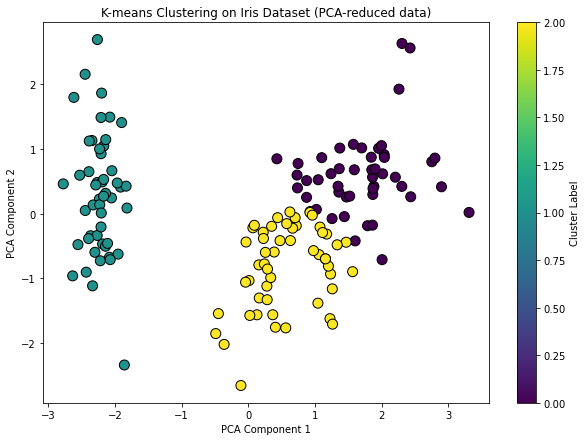

In [25]:
pca = PCA(n_components=2)
data_pca = pca.fit_transform(data_scaled)

plt.figure(figsize=(10, 7))
plt.scatter(data_pca[:, 0], data_pca[:, 1], c=labels, cmap='viridis', marker='o', edgecolor='k', s=100)
plt.title('K-means Clustering on Iris Dataset (PCA-reduced data)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.colorbar(label='Cluster Label')
plt.show()

In the above visualization, while the teal cluster is distinctly separated, the slight overlap between the yellow and dark purple clusters indicates areas where the clusters are more similar, suggesting potential areas for further analysis or refinement in clustering.